In [4]:
import sys
import os

# Point Python to the src/ folder so pipeline.py can be found
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipeline import DataCleaningPipeline

In [7]:
# ── 1. LOAD DATA
df = pd.read_csv('data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
print(df.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [8]:
# ── 2. INITIAL INSPECTION
print(df.dtypes)
print('\nNull counts:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nClass balance:\n', df['Attrition'].value_counts())

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [9]:
# ── 3. RUN PIPELINE
numeric_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                'YearsAtCompany', 'DistanceFromHome']

categorical_cols = ['Attrition', 'BusinessTravel', 'Department',
                    'EducationField', 'Gender', 'JobRole',
                    'MaritalStatus', 'OverTime']

pipeline = (
    DataCleaningPipeline(df)
    .standardize_columns()
    .drop_constants()
    .drop_duplicates()
    .handle_nulls(strategy='median')
    .remove_outliers_iqr([c.lower() for c in numeric_cols])
    .engineer_features()
    .encode_categoricals([c.lower() for c in categorical_cols])
)

clean_df = pipeline.get_clean_data()
print('\nCleaning Report:', pipeline.get_report())

Dropped 3 constant columns: ['employeecount', 'over18', 'standardhours']
Removed 0 duplicate rows.
Imputed nulls in 0 columns.
age: capped 0 outliers.
monthlyincome: capped 114 outliers.
totalworkingyears: capped 63 outliers.
yearsatcompany: capped 104 outliers.
distancefromhome: capped 0 outliers.
Feature engineering complete.
Encoded 8 categorical columns.

Cleaning Report: {'dropped_constant_cols': ['employeecount', 'over18', 'standardhours'], 'duplicates_removed': 0, 'null_cols': {}}


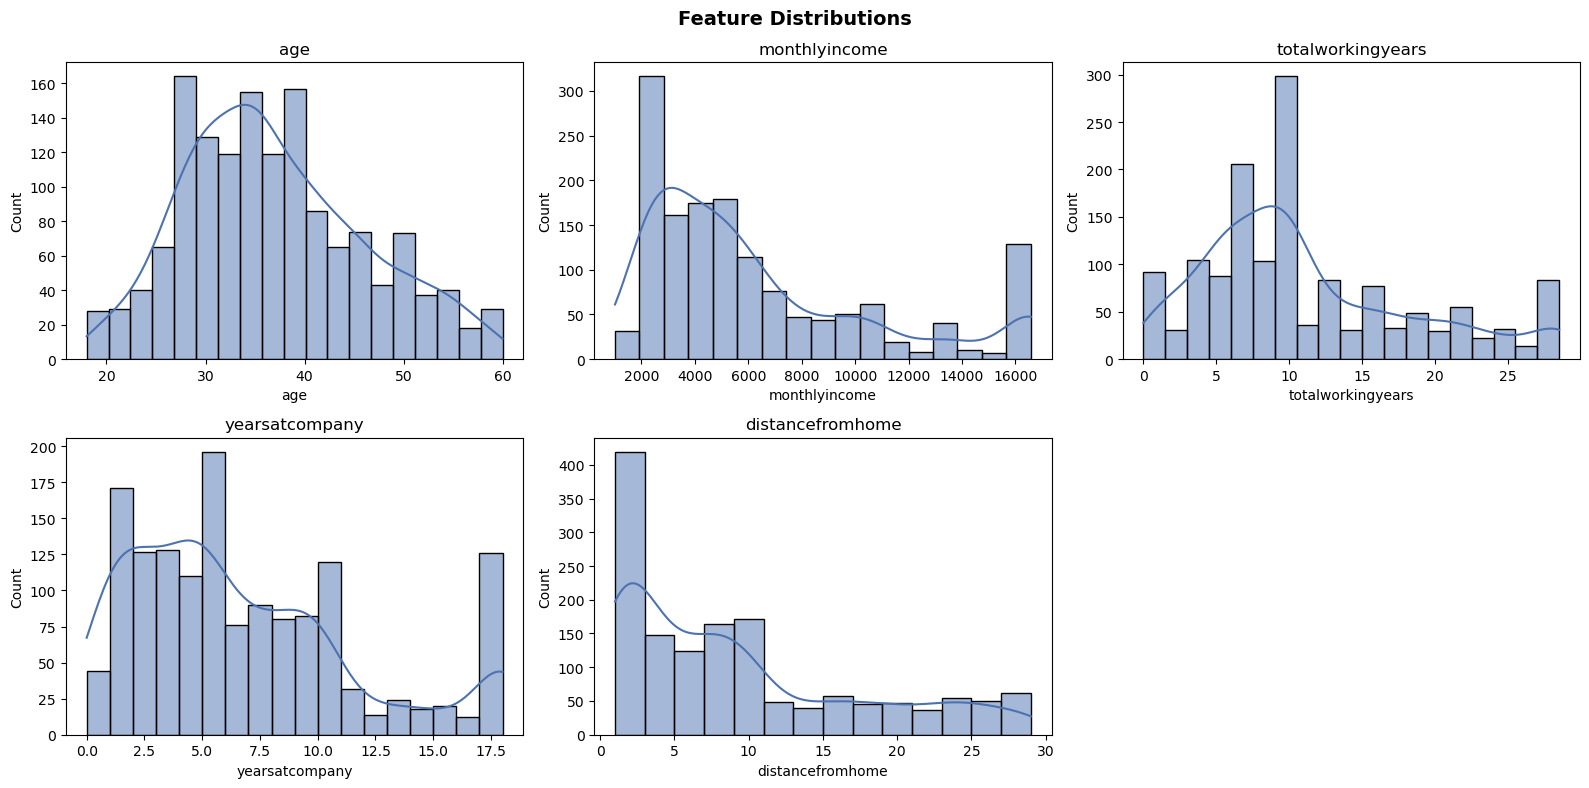

In [15]:
# ── 4. EDA - DISTRIBUTIONS
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['age', 'monthlyincome', 'totalworkingyears',
                          'yearsatcompany', 'distancefromhome']):
    sns.histplot(clean_df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/distributions.png', dpi=150)
plt.show()

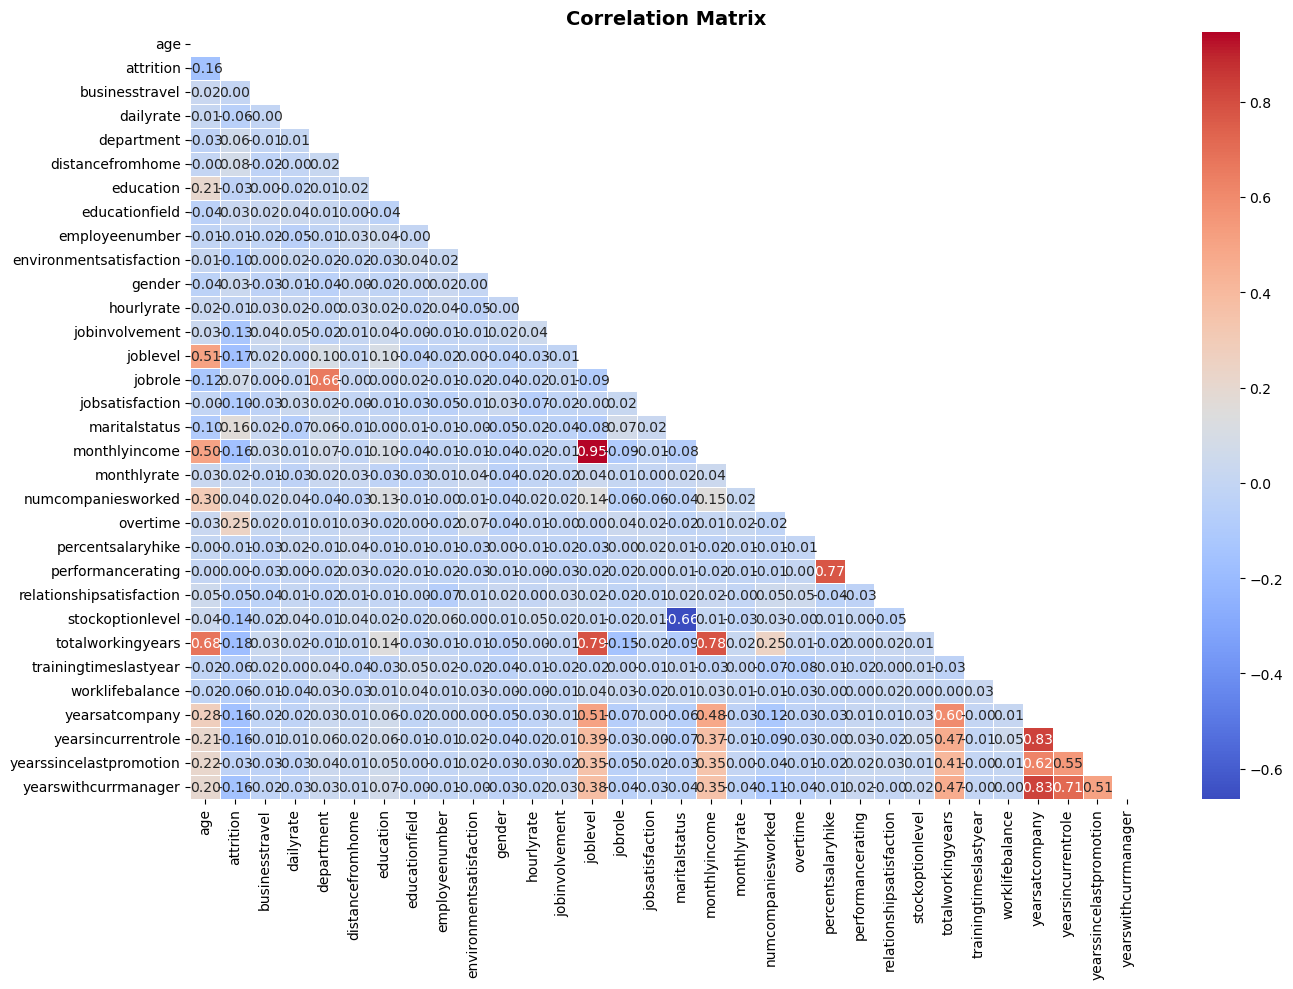

In [14]:
# ── 5. CORRELATION MATRIX
plt.figure(figsize=(14, 10))
corr = clean_df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_matrix.png', dpi=150)
plt.show()

C:\Users\emman\AppData\Local\Temp\ipykernel_23440\137336030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='attrition', palette='Set2', ax=axes[0])
C:\Users\emman\AppData\Local\Temp\ipykernel_23440\137336030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='attrition', y='monthlyincome',


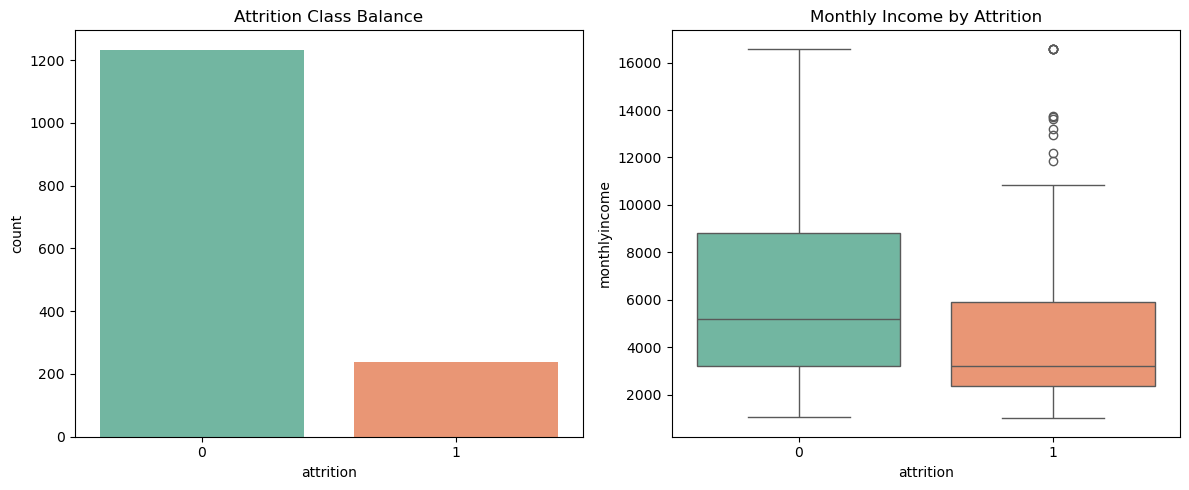

In [17]:
# ── 6. ATTRITION BREAKDOWN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=clean_df, x='attrition', palette='Set2', ax=axes[0])
axes[0].set_title('Attrition Class Balance')
sns.boxplot(data=clean_df, x='attrition', y='monthlyincome',
            palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Income by Attrition')
plt.tight_layout()
plt.savefig('outputs/attrition_breakdown.png', dpi=150)
plt.show()

In [18]:
# ── 7. EXPORT
clean_df.to_csv('outputs/cleaned_data.csv', index=False)
print('Clean dataset saved to outputs/cleaned_data.csv')
print(f'Final shape: {clean_df.shape}')

Clean dataset saved to outputs/cleaned_data.csv
Final shape: (1470, 34)
